<a href="https://colab.research.google.com/github/gurman007/halurust-probing/blob/main/notebooks/phase1_probing_sc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1 — Probing a Frozen Code LLM for Rust Vulnerability Knowledge

**What this notebook does** (one evening on a free Colab T4):

1. Loads your 251 vulnerable/fixed Rust pairs from `Positive/` and `Negative/` folders.
2. Applies the audit exclusions via `halurust_metadata.csv` (upload it alongside the dataset).
3. Runs every sample through **frozen Qwen2.5-Coder-7B (4-bit)** and caches hidden states from **all layers**.
4. Trains a **logistic-regression probe per layer** under **CVE-grouped cross-validation**.
5. Reports **AUC-by-layer** and the headline **pairwise ranking accuracy** (which twin is vulnerable?).
6. Compares against the cheap floors: code length, `unsafe` keyword, TF-IDF.
7. Temporal split: train on pre-2024 CVEs, test on 2024+ (contamination check).

**Before running**: Runtime → Change runtime type → **T4 GPU**.

**Upload** (left sidebar, or mount Drive and edit paths in the Config cell):
- `dataset.zip` containing `Positive/*.rs` and `Negative/*.rs` (identical filenames per pair, `CVE-<Y>-<ID>_CWE-<ID>.rs`)
- `halurust_metadata.csv` (provided with this notebook)

**Decision rule (pre-committed)**: if pairwise ranking under CVE-grouped CV beats **62%** at any layer, the
"model knows more than it says" line is live. If not, the finding is "the signal is shallow" — also reportable.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
#@title 1. Install dependencies (~2 min)
!pip -q install -U transformers accelerate bitsandbytes scikit-learn matplotlib
import torch, numpy as np, pandas as pd, os, re, glob, json, zipfile
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE - switch runtime to T4!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 61.4 MB/s eta 0:00:00
GPU: Tesla T4


In [ ]:
#@title 2. Config — edit paths here if using Drive
MODEL_ID     = "Qwen/Qwen2.5-Coder-7B"   # base model (not -Instruct) for representation study
DATASET_ZIP  = "dataset.zip"              # zip with Positive/ and Negative/
METADATA_CSV = "halurust_metadata.csv"
CACHE_FILE   = "hidden_states.npz"        # copy this to Drive after Step 5 - it is the expensive artifact
MAX_TOKENS   = 4096                        # truncate very long functions
SEED         = 0
np.random.seed(SEED); torch.manual_seed(SEED)

# To persist the cache across sessions, uncomment:
# from google.colab import drive; drive.mount('/content/drive')
# CACHE_FILE = "/content/drive/MyDrive/halurust/hidden_states.npz"

In [ ]:
#@title 2b. Materialize embedded data (no uploads needed)
import base64, os
_DZ='''...
APgB+AFWzAAAv+EHAAAA
'''
_MD='''...
MS0wMy0wNSxubyxPSywyNTcNCg==
'''
open('dataset.zip','wb').write(base64.b64decode(_DZ))
open('halurust_metadata.csv','wb').write(base64.b64decode(_MD))
print('materialized:', os.path.getsize('dataset.zip'), 'bytes zip,', os.path.getsize('halurust_metadata.csv'), 'bytes csv')

materialized: 568875 bytes zip, 25099 bytes csv


In [ ]:
#@title 3. Load pairs + metadata, apply audit exclusions
if os.path.exists(DATASET_ZIP):
    with zipfile.ZipFile(DATASET_ZIP) as z: z.extractall("data")
POS = sorted(glob.glob("data/**/Positive/*.rs", recursive=True) or glob.glob("Positive/*.rs"))
NEG = sorted(glob.glob("data/**/Negative/*.rs", recursive=True) or glob.glob("Negative/*.rs"))
assert POS and NEG, "Could not find Positive/ and Negative/ .rs files - check the zip layout"

meta = pd.read_csv(METADATA_CSV)
meta["date"] = meta[["advisory_date","commit_date"]].fillna("").max(axis=1)
ok_cves      = set(meta.loc[meta.audit_verdict.eq("OK"), "cve"])
flagged      = set(meta.loc[~meta.audit_verdict.eq("OK"), "cve"])
never_patched= set(meta.loc[meta.never_patched_upstream.eq("yes"), "cve"])
cve2 = meta.set_index("cve").to_dict("index")

def parse(fp):
    m = re.match(r"(CVE-\d{4}-\d+)_?(CWE-[\w-]+)?", os.path.basename(fp))
    return (m.group(1), m.group(2) or "") if m else (None, "")

neg_by_cve = {parse(fp)[0]: fp for fp in NEG}
samples = []   # one row per code sample; pairs share a cve
for fp in POS:
    cve, cwe = parse(fp)
    if cve is None or cve not in neg_by_cve:  continue
    if cve in flagged:                        continue   # audit: wrong/missing/no-delta commits
    for path, label in [(fp, 1), (neg_by_cve[cve], 0)]:
        codetxt = open(path, encoding="utf-8", errors="replace").read()
        mrow = cve2.get(cve, {})
        samples.append(dict(cve=cve, cwe=cwe, label=label, code=codetxt,
                            crate=str(mrow.get("crate","?")), date=str(mrow.get("date","")),
                            never_patched=cve in never_patched))
df = pd.DataFrame(samples)
print(f"pairs kept: {df.cve.nunique()}   samples: {len(df)}   excluded (audit): {len(flagged & set(neg_by_cve))}")
print(f"never-patched stratum (kept, reported separately): {df[df.never_patched].cve.nunique()} pairs")
print(f"post-2024 pairs (temporal test set): {df[df.date >= '2024'].cve.nunique()}")

pairs kept: 228   samples: 460   excluded (audit): 21
never-patched stratum (kept, reported separately): 5 pairs
post-2024 pairs (temporal test set): 56


In [ ]:
#@title 4. Cheap floors first — direction learned via grouped CV (honest version)
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import roc_auc_score
import numpy as np

eqlen=set()
for cve,g in df.groupby("cve"):
    if set(g.label)=={0,1}:
        lv=len(g.loc[g.label==1,"code"].iloc[0]); lf=len(g.loc[g.label==0,"code"].iloc[0])
        if abs(lv-lf)<=20: eqlen.add(cve)
print(f"near-equal-length pairs (|dlen|<=20 chars): {len(eqlen)}")

def pairwise_acc(scores, subset=None):
    a=n=0
    for cve,g in df.assign(s=scores).groupby("cve"):
        if subset is not None and cve not in subset: continue
        if set(g.label)=={0,1}:
            sv=g.loc[g.label==1,"s"].iloc[0]; sf=g.loc[g.label==0,"s"].iloc[0]
            a += 1.0 if sv>sf else (0.5 if sv==sf else 0.0); n+=1
    return a/n if n else float("nan")

def grouped_cv_scores(X):
    X=np.asarray(X,dtype=float).reshape(len(df),-1)
    s=np.zeros(len(df))
    for tr,te in GroupKFold(5).split(X, df.label, groups=df.cve):
        m=LogisticRegression(max_iter=3000).fit(X[tr], df.label.iloc[tr]); s[te]=m.predict_proba(X[te])[:,1]
    return s

floors={}
floors["length"]  = grouped_cv_scores(df.code.str.len().values[:,None])
floors["unsafe"]  = grouped_cv_scores(df.code.str.count(r"\bunsafe\b").values[:,None])
Xt=TfidfVectorizer(max_features=5000, token_pattern=r"\S+").fit_transform(df.code).toarray()
floors["tfidf"]   = grouped_cv_scores(Xt)
print(f"\n{'floor':10s}{'AUC':>7s}{'pairwise':>10s}{'eq-len pw':>11s}")
for k,s in floors.items():
    print(f"{k:10s}{roc_auc_score(df.label,s):7.3f}{pairwise_acc(s):10.3f}{pairwise_acc(s,eqlen):11.3f}")
print("Reference (full corpus, Aug 2026): length pairwise ~0.807. Probe must beat 0.807 overall or ~0.60 on eq-len.")

near-equal-length pairs (|dlen|<=20 chars): 36

floor         AUC  pairwise  eq-len pw
length      0.544     0.805      0.681
unsafe      0.486     0.502      0.514
tfidf       0.567     0.638      0.611
Reference (full corpus, Aug 2026): length pairwise ~0.807. Probe must beat 0.807 overall or ~0.60 on eq-len.


In [ ]:
#@title 5. Extract hidden states — the one expensive cell (~30-60 min). Cached forever after.
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

if os.path.exists(CACHE_FILE):
    print("cache found - skipping extraction")
else:
    tok = AutoTokenizer.from_pretrained(MODEL_ID)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, device_map="auto", torch_dtype=torch.float16,
        quantization_config=BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16))
    model.eval()

    last_tok, mean_pool = [], []
    with torch.no_grad():
        for i, codetxt in enumerate(df.code):
            enc = tok(codetxt, return_tensors="pt", truncation=True, max_length=MAX_TOKENS).to(model.device)
            hs = model(**enc, output_hidden_states=True).hidden_states     # tuple: (n_layers+1) x [1, T, d]
            last_tok.append(torch.stack([h[0, -1] for h in hs]).float().cpu().numpy())      # [L+1, d]
            mean_pool.append(torch.stack([h[0].mean(0) for h in hs]).float().cpu().numpy()) # [L+1, d]
            if i % 25 == 0: print(f"{i}/{len(df)}")
    np.savez_compressed(CACHE_FILE,
                        last=np.stack(last_tok), mean=np.stack(mean_pool),
                        cve=df.cve.values, label=df.label.values)
    print("saved", CACHE_FILE, "- copy this file to Drive now.")

cache = np.load(CACHE_FILE, allow_pickle=True)
H_last, H_mean = cache["last"], cache["mean"]        # [N, L+1, d]
assert list(cache["cve"]) == list(df.cve), "cache/dataset mismatch - delete cache and re-extract"
N, L1, d = H_last.shape
print(f"hidden states: {N} samples x {L1} layers x {d} dims")

config.json:   0%|          | 0.00/668 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.31k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

0/460
25/460
50/460
75/460
100/460
125/460
150/460
175/460
200/460
225/460
250/460
275/460
300/460
325/460
350/460
375/460
400/460
425/460
450/460
saved hidden_states.npz - copy this file to Drive now.
hidden states: 460 samples x 29 layers x 3584 dims


last-token layer  0: AUC 0.515  pairwise 0.518  eq-len 0.500
last-token layer  1: AUC 0.541  pairwise 0.614  eq-len 0.639
last-token layer  2: AUC 0.541  pairwise 0.586  eq-len 0.556
last-token layer  3: AUC 0.549  pairwise 0.610  eq-len 0.667
last-token layer  4: AUC 0.575  pairwise 0.607  eq-len 0.611
last-token layer  5: AUC 0.552  pairwise 0.629  eq-len 0.542
last-token layer  6: AUC 0.553  pairwise 0.636  eq-len 0.528
last-token layer  7: AUC 0.560  pairwise 0.649  eq-len 0.625
last-token layer  8: AUC 0.550  pairwise 0.656  eq-len 0.625
last-token layer  9: AUC 0.558  pairwise 0.662  eq-len 0.639
last-token layer 10: AUC 0.571  pairwise 0.656  eq-len 0.528
last-token layer 11: AUC 0.586  pairwise 0.693  eq-len 0.611
last-token layer 12: AUC 0.582  pairwise 0.675  eq-len 0.583
last-token layer 13: AUC 0.570  pairwise 0.682  eq-len 0.667
last-token layer 14: AUC 0.573  pairwise 0.678  eq-len 0.681
last-token layer 15: AUC 0.555  pairwise 0.656  eq-len 0.708
last-token layer 16: AUC

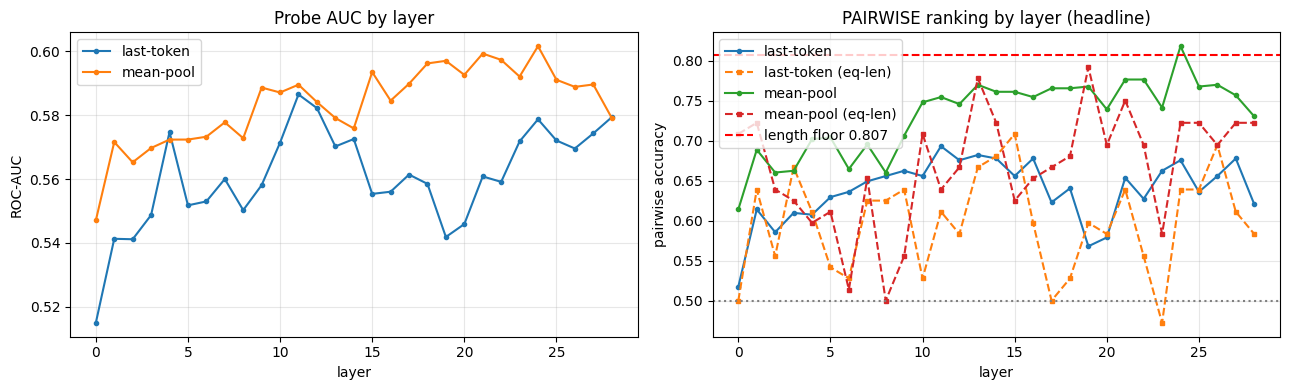


BEST overall pairwise: 0.818 (mean-pool, L24)  [floor 0.807]
BEST eq-len pairwise:  0.792 (mean-pool, L19)  [floor 0.5]


In [ ]:
#@title 6. Probe every layer under CVE-grouped CV  →  the two headline curves
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

def probe_layer(H, layer):
    X = H[:, layer, :]
    pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, C=0.5))
    s = np.zeros(N)
    for tr, te in GroupKFold(5).split(X, df.label, groups=df.cve):
        pipe.fit(X[tr], df.label.iloc[tr]); s[te] = pipe.predict_proba(X[te])[:,1]
    return roc_auc_score(df.label, s), pairwise_acc(s), s

results = {}
for name, H in [("last-token", H_last), ("mean-pool", H_mean)]:
    aucs, pws, pwe = [], [], []
    for l in range(L1):
        a, p, s = probe_layer(H, l); aucs.append(a); pws.append(p); pwe.append(pairwise_acc(s, eqlen))
        print(f"{name:10s} layer {l:2d}: AUC {a:.3f}  pairwise {p:.3f}  eq-len {pwe[-1]:.3f}")
    results[name] = (aucs, pws, pwe)

fig, axes = plt.subplots(1, 2, figsize=(13,4))
for name,(aucs,pws,pwe) in results.items():
    axes[0].plot(aucs, marker="o", ms=3, label=name)
    axes[1].plot(pws, marker="o", ms=3, label=name)
    axes[1].plot(pwe, marker="s", ms=3, ls="--", label=name+" (eq-len)")
axes[0].set(title="Probe AUC by layer", xlabel="layer", ylabel="ROC-AUC")
axes[1].set(title="PAIRWISE ranking by layer (headline)", xlabel="layer", ylabel="pairwise accuracy")
axes[1].axhline(0.807, color="red", ls="--", label="length floor 0.807")
axes[1].axhline(0.50, color="gray", ls=":")
for ax in axes: ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig("phase1_curves.png", dpi=150); plt.show()

best = max((max(p), n, int(np.argmax(p))) for n,(a,p,e) in results.items())
beste = max((max(e), n, int(np.argmax(e))) for n,(a,p,e) in results.items())
print(f"\nBEST overall pairwise: {best[0]:.3f} ({best[1]}, L{best[2]})  [floor 0.807]")
print(f"BEST eq-len pairwise:  {beste[0]:.3f} ({beste[1]}, L{beste[2]})  [floor 0.5]")

In [ ]:
#@title 7. Temporal split (contamination check) + never-patched stratum
best_pool, best_layer = best[1], best[2]
H = H_last if best_pool == "last-token" else H_mean
X = H[:, best_layer, :]

pre  = df.index[df.date <  "2024"].to_numpy()
post = df.index[df.date >= "2024"].to_numpy()
pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, C=0.5)).fit(X[pre], df.label.iloc[pre])
s_post = pipe.predict_proba(X[post])[:,1]
sub = df.iloc[post].assign(score=s_post)
acc, n = 0, 0
for cve, g in sub.groupby("cve"):
    if set(g.label)=={0,1}:
        acc += float(g.loc[g.label==1,"score"].iloc[0] > g.loc[g.label==0,"score"].iloc[0]); n += 1
print(f"TEMPORAL  train<2024 ({df.iloc[pre].cve.nunique()} CVEs) -> test 2024+ ({n} pairs): pairwise {acc/n:.3f}")
print("  holds up  -> understanding, not memorization")
print("  collapses -> the grouped-CV number was partly memory (also a finding)")

# never-patched stratum: 'safe' side is a later voluntary rewrite, not a released fix
_,_,s_all = probe_layer(H, best_layer)
npd = df[df.never_patched].assign(score=s_all[df.never_patched.values])
acc2,n2 = 0,0
for cve,g in npd.groupby("cve"):
    if set(g.label)=={0,1}: acc2+=float(g.loc[g.label==1,"score"].iloc[0]>g.loc[g.label==0,"score"].iloc[0]); n2+=1
if n2: print(f"NEVER-PATCHED stratum ({n2} pairs): pairwise {acc2/n2:.3f}  (report separately in the paper)")

TEMPORAL  train<2024 (172 CVEs) -> test 2024+ (56 pairs): pairwise 0.821
  holds up  -> understanding, not memorization
  collapses -> the grouped-CV number was partly memory (also a finding)
NEVER-PATCHED stratum (5 pairs): pairwise 0.800  (report separately in the paper)


In [ ]:
#@title 8. Error analysis — read these 20 files by hand before doing ANYTHING else
_,_,s = probe_layer(H, best_layer)
rows=[]
for cve, g in df.assign(score=s).groupby("cve"):
    if set(g.label)=={0,1}:
        margin = g.loc[g.label==1,"score"].iloc[0] - g.loc[g.label==0,"score"].iloc[0]
        rows.append((margin, cve, g.cwe.iloc[0], g.crate.iloc[0]))
rows.sort()
print("=== 10 WORST pairs (probe most confidently backwards) ===")
for m,c,w,cr in rows[:10]:  print(f"  margin {m:+.3f}  {c}  {w}  {cr}")
print("=== 10 BEST pairs ===")
for m,c,w,cr in rows[-10:]: print(f"  margin {m:+.3f}  {c}  {w}  {cr}")
pd.DataFrame(rows, columns=["margin","cve","cwe","crate"]).to_csv("pair_margins.csv", index=False)
print("\nSaved pair_margins.csv - open the worst pairs' .rs files and read them. What do they share?")

=== 10 WORST pairs (probe most confidently backwards) ===
  margin -0.793  CVE-2021-28031  CWE-415  scratchpad
  margin -0.352  CVE-2020-35923  CWE-416  ordered-float crate
  margin -0.348  CVE-2024-36400  CWE-331  nano-id
  margin -0.326  CVE-2021-25900  CWE-787  smallvec crate
  margin -0.276  CVE-2023-42811  CWE-347  aes-gcm
  margin -0.190  CVE-2021-41153  CWE-670  evm crate
  margin -0.178  CVE-2021-45710  CWE-362  tokio
  margin -0.154  CVE-2021-43620  CWE-20  fruity
  margin -0.130  CVE-2024-52813  CWE-223  matrix-sdk-crypto
  margin -0.117  CVE-2020-35909  CWE-20  multihash
=== 10 BEST pairs ===
  margin +0.934  CVE-2020-36210  CWE-908  autorand crate
  margin +0.942  CVE-2019-16214  CWE-701  Libra Core
  margin +0.951  CVE-2021-39216  CWE-416  wasmtime
  margin +0.961  CVE-2024-58266  CWE-116  shlex
  margin +0.961  CVE-2021-29937  CWE-908  telemetry
  margin +0.975  CVE-2022-39294  CWE-400  conduit-hyper
  margin +0.986  CVE-2021-28033  CWE-908  byte_struct
  margin +0.997  C

## Decision table (REVISED)

| Outcome (grouped CV) | Reading |
|---|---|
| Overall pairwise > 0.81 | Beats the length shortcut — strong |
| Eq-length pairwise > 0.60 | Real non-length signal |
| Neither | Signal <= patch-shape/lexical floors — pivot framing |
| Temporal << grouped-CV | Part of the signal is memorization (also a finding) |

CPU pilot reference (0.5B): overall 0.708, eq-len 0.730, AUC 0.586; mean-pool > last-token.